# 6 — A problem, end to end

The other five notebooks each show a piece. This one is the whole loop, on one
problem: **propose an architecture, find out what is wrong with it, fix that,
and check the fix worked.** Four times, and the fourth is the interesting one.

The problem is made up but its shape is not. Two channels of evidence about a
person, and a thing to predict from them. One channel is what the research is
*about*; the other is what happens to be lying around.

In [1]:
import math

import torch

import soma_next.torch  # noqa: F401
from soma_next import Ctx, Graph, Node, Opaque, Recorder, Store
from soma_next.data import contribution, leaned, leaning, shares
from soma_next.health import about, alerts, diagnose, overlaid, profile, seen
from soma_next.record import progress
from soma_next.torch import Audit, Trainer, architecture, parameters

torch.manual_seed(0)
store = Store(__import__("tempfile").mkdtemp())

WIDTH, ROWS, OUT = 8, 256, 4
#: Four things to predict and not one, so that a narrow join is a real one: a
#: bottleneck of one carries a scalar perfectly well.


def people(how_many=6, answer="disclosure", seed=0):
    """Batches of two channels about a person, and something to predict.

    `answer` says which channel the signal is really in — which, in a real
    study, is exactly the thing nobody knows.
    """
    torch.manual_seed(seed)
    weights = torch.randn(WIDTH, OUT)
    made = []
    for _ in range(how_many):
        said = {one: torch.randn(ROWS, WIDTH) for one in ("symptoms", "disclosure")}
        target = torch.tanh(said[answer] @ weights) + 0.05 * torch.randn(ROWS, OUT)
        made.append(({one: Opaque(what) for one, what in said.items()}, target))
    return made


DATA = people()


def scored(g, data=None):
    """The mean loss, with nothing trained."""
    with torch.no_grad():
        data = data or DATA
        return sum(
            float(torch.nn.functional.mse_loss(g.forward(one), target)) for one, target in data
        ) / len(data)


def fit(g, run, *, steps=200, lr=0.02, auditing=True, data=None, how="adam"):
    """One short training run, audited and written down."""
    make = {"adam": torch.optim.Adam, "sgd": torch.optim.SGD}[how]
    t = Trainer(
        g,
        objective=torch.nn.functional.mse_loss,
        optimizer=make(parameters(g), lr=lr),
        auditing=Audit(inside=True) if auditing else None,
        watching=Recorder(store, run=run, summarising=["loss"]),
    )
    data = data or DATA
    for which in range(steps):
        t.step(data[which % len(data)])
    return g

## The architecture, proposed

One branch per channel so that each can be looked at on its own — which is the
point of declaring a graph rather than writing one `nn.Module` — and a head
that joins them.

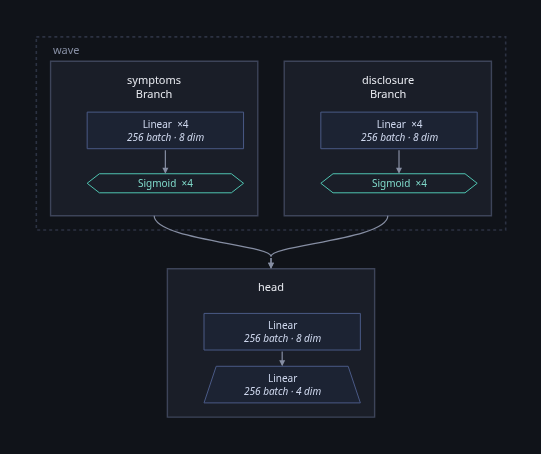

In [2]:
class Branch(Node):
    """Reads its own channel out of the input and encodes it."""

    def __init__(self, key, depth=4, activation="sigmoid"):
        self.key = key
        self.net = torch.nn.Sequential(
            *[
                m
                for _ in range(depth)
                for m in (
                    torch.nn.Linear(WIDTH, WIDTH),
                    {"sigmoid": torch.nn.Sigmoid(), "gelu": torch.nn.GELU()}[activation],
                )
            ]
        )

    def forward(self, said, ctx):
        return Opaque(self.net(said[self.key]))

    def parameters(self):
        return list(self.net.parameters())


class Head(Node):
    def __init__(self, squeeze=WIDTH):
        self.down = torch.nn.Linear(2 * WIDTH, squeeze)
        self.up = torch.nn.Linear(squeeze, OUT)

    def forward(self, said, ctx):
        joined = torch.cat(list(said.values()), dim=1)
        return Opaque(self.up(torch.relu(self.down(joined))))

    def parameters(self):
        return list(self.down.parameters()) + list(self.up.parameters())


def built(depth=4, activation="sigmoid", squeeze=WIDTH):
    return Graph.somatize(
        (
            Branch("symptoms", depth, activation).named("symptoms")
            | Branch("disclosure", depth, activation).named("disclosure")
        )
        >> Head(squeeze).named("head")
    )


first = built()
first.figure(inside=architecture(first, DATA[0][0]))

Two branches side by side inside a wave — they run at once — and a head that
joins them. Every layer says what it is and what shape it produces.

## Symptom 1 — it does not learn at all

Train it with plain SGD and look at what happened.

In [3]:
fit(first, "attempt-1", how="sgd", lr=0.1)
print("loss:", round(scored(first), 4))
alerts(store, run="attempt-1")

loss: 0.7104


attempt-1 — 8 finding(s)
  ⚠ symptoms: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ symptoms.net.0: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ symptoms.net.2: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ symptoms.net.4: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ disclosure: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ disclosure.net.0: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ disclosure.net.2: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ disclosure.net.4: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it

`STALLED` on **every layer of both branches**. The profile says the rest:

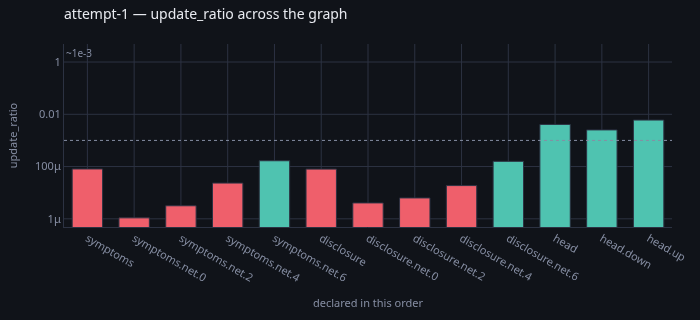

In [4]:
profile(store, run="attempt-1", of="update_ratio")

A staircase, and every bar far under the `1e-3` a healthy layer sits at. That
is a **depth profile** and it has one cause: σ′(z) ≤ 0.25 per layer, so the
backpropagated signal shrinks geometrically. Four sigmoids is enough.

### The fix: a non-saturating activation

In [5]:
second = built(activation="gelu")
fit(second, "attempt-2", how="sgd", lr=0.1)

print("loss:", round(scored(second), 4))
print("flags:", diagnose(store, run="attempt-2"))

loss: 0.708
flags: {'symptoms.net.0': ['STALLED'], 'symptoms.net.2': ['STALLED'], 'symptoms.net.4': ['STALLED']}


## Symptom 2 — it half worked, and the residue is the clue

The `disclosure` branch is clean now. The `symptoms` branch is **still**
`STALLED`, and the loss barely moved.

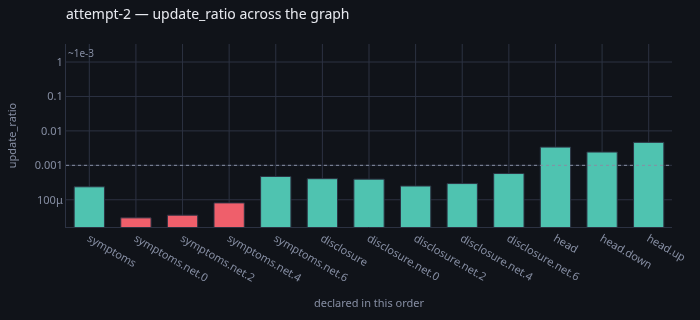

In [6]:
profile(store, run="attempt-2", of="update_ratio")

Both branches went up by about an order of magnitude, which is the fix
working — and they are both still under `1e-3`, which is the fix not being
enough. Plain SGD cannot get this network moving.

### The fix: an optimizer that scales its own steps

In [7]:
third = built(activation="gelu")
fit(third, "attempt-3", lr=0.02)

print("loss :", round(scored(third), 4))
print("flags:", diagnose(store, run="attempt-3") or "nothing tripped")

loss : 0.0224
flags: nothing tripped


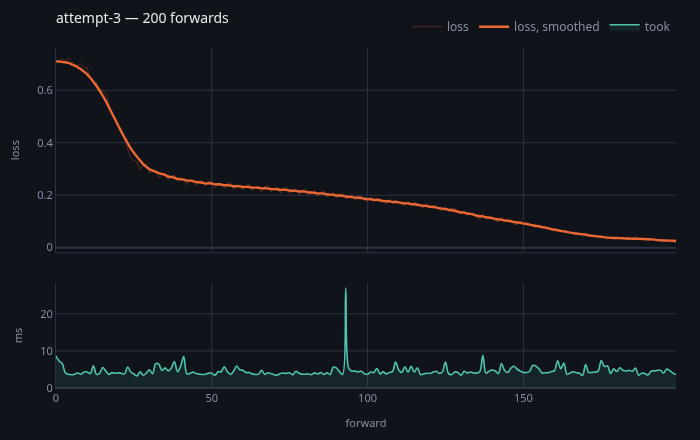

In [8]:
progress(store, run="attempt-3")

**Nothing tripped**, and the loss fell by two orders of magnitude. Every check
in `soma_next.health` now says this network is fine.

Hold on to that, because it is true and it is not the end.

## Symptom 3 — the step is too big

The same architecture with the rate turned up. This is the other end of the
very number that said `STALLED`.

In [9]:
hot = built(activation="gelu")
fit(hot, "attempt-4", lr=0.5)

alerts(store, run="attempt-4")

attempt-4 — 24 finding(s)
  ⚠ symptoms: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ symptoms: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ symptoms.net.0: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ symptoms.net.0: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ symptoms.net.2: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ symptoms.net.2: SATURATED
      most of the output is pinned where the derivative is nothing
  ⚠ symptoms.net.2: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ symptoms.net.4: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ symptoms.net.4: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ symptoms.net.6: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ symptoms.net.6: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ disclosure: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ disclosure: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ disclosure.net.0: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ disclosure.net.0: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ disclosure.net.2: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ disclosure.net.2: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ disclosure.net.4: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ disclosure.net.4: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ disclosure.net.6: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ disclosure.net.6: SATURATED
      most of the output is pinned where the derivative is nothing
  ⚠ disclosure.net.6: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it
  ⚠ head.down: VANISHING
      this node is barely being trained — look at the depth profile, not at this node alone: it is the early layers that go quiet first
  ⚠ head.down: STALLED
      the update is tiny next to the weights; the rate is too low for this node, or nothing is reaching it

Not one flag: a **wreck**. `SATURATED` where the activations were driven to
the far end of their range, `DEAD` where they came back as nothing,
`VANISHING` because a saturated layer has no derivative to pass on, and
`STALLED` because nothing can move any more.

That is worth seeing as it is rather than tidied into one word. A rate too
high does not politely announce itself and then stop — by the time the loss
says anything, the network has already been broken in four ways, and reading
the flags is what tells you they are **one** event and not four.

`OVERSTEPPING` is the mild end of the same number, and it is what you would
have caught a few steps earlier.

## Symptom 4 — the join is too narrow

A bottleneck of one: everything downstream is a function of a single number,
however wide the branches were.

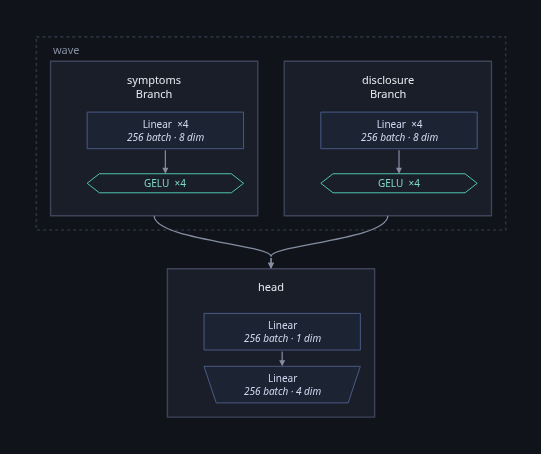

In [10]:
pinched = built(activation="gelu", squeeze=1)
fit(pinched, "attempt-5", lr=0.02)

pinched.figure(inside=architecture(pinched, DATA[0][0]))

**The picture is the diagnosis** — `16 → 1 → 1` — and it is why the shape is
written on every layer. No flag had to say a word.

In [11]:
print("squeezed to one  :", round(scored(pinched), 4))
print("squeezed to eight:", round(scored(third), 4))

squeezed to one  : 0.362
squeezed to eight: 0.0224


## Symptom 5 — it learns, and it learns the wrong thing

Back to `third`, the one where nothing tripped and the loss fell by two orders
of magnitude. Everything the other notebooks can measure says it is fine.

And the whole reason for the study was the **symptoms** channel.

In [12]:
print("flags:", diagnose(store, run="attempt-3") or "nothing tripped")
print("loss :", round(scored(third), 4))

flags: nothing tripped
loss : 0.0224


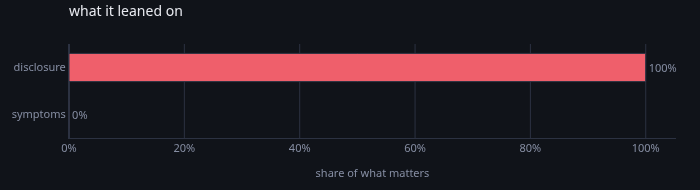

In [13]:
said = contribution(third, DATA, objective=torch.nn.functional.mse_loss)
leaned(said)

The channel the work is about is worth **nothing**. Shuffle it and the score
does not move.

No gradient was ever going to say that. The network is healthy; it is healthy
at learning something else.

In [14]:
print(leaning(said))
print()
print(about("IGNORED_INPUT"))

{'symptoms': ['IGNORED_INPUT(symptoms)'], 'disclosure': ['SOLE_RELIANCE(disclosure)']}

the model is not using this input: taking it away costs nothing. If this is the channel the work is about, nothing in the network is the problem


### The fix is not in the network

There are three honest possibilities, and two of them are not code:

1. the signal is **not in that channel** — a finding about the data, and the
   end of a research question rather than a bug;
2. it is there and the encoder cannot reach it — which the profile would have
   shown, and does not;
3. the other channel is a **shortcut** that makes learning the first one
   unnecessary.

The third is the one you can test, and the test is to take the shortcut away.

In [15]:
alone = built(activation="gelu")
only = [
    ({"symptoms": one["symptoms"], "disclosure": Opaque(torch.zeros(ROWS, WIDTH))}, y)
    for one, y in DATA
]
fit(alone, "attempt-6", lr=0.02, auditing=False, data=only)

print("trained on symptoms alone:", round(scored(alone, only), 4))
print("everything, for comparison:", round(scored(third), 4))
print("flags while doing it:", diagnose(store, run="attempt-6") or "nothing tripped")

trained on symptoms alone: 0.6772
everything, for comparison: 0.0224
flags while doing it: nothing tripped


It cannot be learnt from the symptoms channel at all, and the network was
healthy the whole time it failed to. So it is the first case, and it is an
**answer**: the predictive signal is not where the study assumed it was.

That is the finding those months were spent not having.

## The loop

| | what said it | what fixed it |
|---|---|---|
| it does not learn | `STALLED` everywhere, and the depth profile | a non-saturating activation |
| it half works | `STALLED` on one branch, the profile still low | an optimizer that scales its steps |
| the step is too big | `SATURATED`, `DEAD`, `VANISHING` at once | the rate |
| the join is too narrow | the **shapes on the figure** | a wider squeeze |
| it learns the wrong thing | `IGNORED_INPUT` | nothing in the network |

Three of the five are read off a number measured while it ran. One is read off
the picture. And the last is not a bug at all — it is the study's actual
result, arrived at in an afternoon instead of a season.

The last one is also the only one where **every other check said the network
was fine**, which is exactly why it is a separate question and not a flag on
the same list.

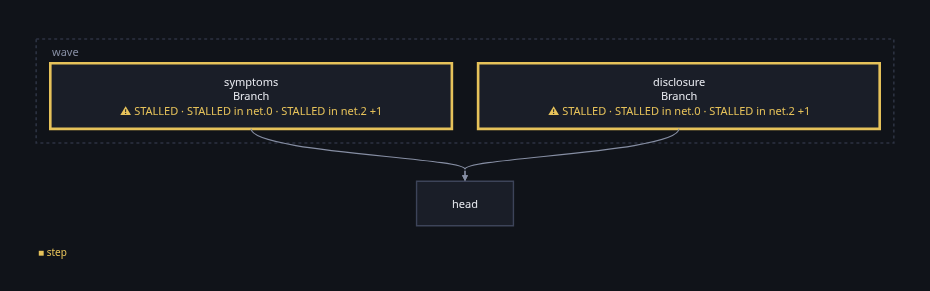

In [16]:
overlaid(first, store, run="attempt-1")